# NLP Sentiment Analysis

## Summary
This project presents a proof of concept for sentiment analysis of tweets mentioning Apple and Google. The business objective is to evaluate brand perception by classifying user-generated content as positive, negative, or neutral. Such insights are valuable for marketing teams and competitive benchmarking. The dataset consists of tweets annotated for sentiment, making it well-suited for supervised machine learning classification.

Data preparation involved several NLP-specific cleaning steps. Tweets were preprocessed by removing URLs, mentions, hashtags, and non-alphabetic characters, converting text to lowercase, and filtering out English stopwords using the NLTK library. The cleaned text was then transformed into numerical features using TF-IDF vectorization (scikit-learn, 5,000 maximum features). This representation captures word importance while reducing dimensionality, enabling efficient training of linear classifiers.

For modeling, we first explored binary sentiment classification (positive vs. negative) and then extended the approach to multiclass classification (adding neutral). Logistic Regression from scikit-learn was selected due to its strong baseline performance in text classification and interpretability. Hyperparameters such as regularization were tuned, and class imbalance was noted as a limitation. The dataset was split into training and test sets using stratified sampling to preserve class distributions.

Evaluation was conducted using accuracy, precision, recall, F1-score, and confusion matrices. Results showed that the model performed well overall, particularly for positive and neutral classes, while negative sentiment remained more challenging. Future improvements may include experimenting with n-grams, adjusting class weights, and leveraging advanced models such as SVMs or transformer-based architectures (e.g., DistilBERT).



## Business Understanding
In this notebook, we analyze public sentiment toward Apple and Google by processing user-generated tweets. This type of analysis is crucial for reputation management and competitive benchmarking. By predicting whether a tweet expresses positive, negative, or neutral sentiment, businesses can track brand perception in real time.


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

data_path = Path('./tweets_sentiment.csv')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rocksonnoel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Loading Data

In [60]:
df = pd.read_csv(data_path, encoding='latin1') 
df = df.rename(columns={
    'tweet_text': 'tweet',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
})

df['sentiment'] = df['sentiment'].replace({
    'Positive emotion': 'positive',
    'Negative emotion': 'negative',
    'No emotion toward brand or product': 'neutral',
    "I can't tell": "neutral"
})
df.head()

,tweet,emotion_in_tweet_is_directed_at,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,negative
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,positive
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,positive
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,negative
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,positive


In [61]:
df['sentiment'].value_counts()

sentiment
neutral     5545
positive    2978
negative     570
Name: count, dtype: int64

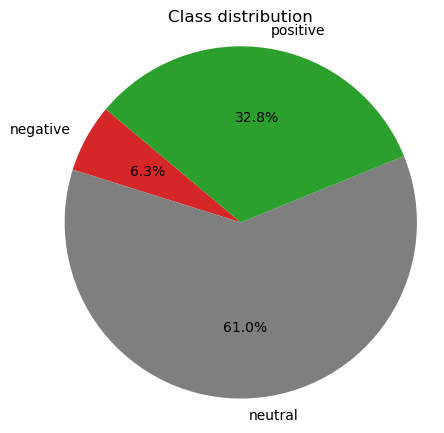

In [62]:
# Class distribution pie chart
counts = df['sentiment'].value_counts().reindex(['negative','neutral','positive']).fillna(0)
labels = counts.index.tolist()
colors = ['#d62728', '#7f7f7f', '#2ca02c']
plt.figure(figsize=(5,5))
plt.pie(counts.values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Class distribution')
plt.axis('equal')
plt.show()


## Data Preparation
Before training a machine learning model, text data must be carefully cleaned. Tweets often include noise such as hashtags, mentions, and URLs that do not contribute to sentiment. We applied the following steps:
- Removal of links, mentions, and special characters using regular expressions (`re`).
- Lowercasing all text and removing stopwords with NLTK.
- Token filtering to keep only alphabetic content.
- Vectorization with TF-IDF (scikit-learn) to capture term importance while limiting dimensionality to 5,000 features.

These steps ensure that the model learns from meaningful linguistic patterns rather than irrelevant tokens.


In [63]:
def clean_tweet(tweet):
    tweet = re.sub(r'http\S+|www\S+', '', str(tweet))
    tweet = re.sub(r'@\w+|#\w+', '', tweet)
    tweet = re.sub(r'[^a-zA-Z\s]', '', tweet)
    tweet = tweet.lower().split()
    tweet = [word for word in tweet if word not in stop_words]
    return ' '.join(tweet)

df['clean_text'] = df['tweet'].apply(clean_tweet)
df[['tweet','clean_text']].head()

,tweet,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting dead need upgrade plugin...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait also sale
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...


## Vectorisation (TF-IDF)

In [64]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

## Modeling
We first approached the task as binary classification (positive vs. negative) and then expanded to multiclass classification (positive, negative, neutral). Logistic Regression from scikit-learn was chosen as a strong baseline model for text classification because of its robustness and efficiency.

Hyperparameters were tuned for regularization strength, and stratified train-test split was used to address class imbalance. Future experiments could involve SVMs, Random Forests, or deep learning approaches such as transformer models (BERT/DistilBERT).


              precision    recall  f1-score   support

    negative       0.50      0.67      0.57       114
    positive       0.93      0.87      0.90       596

    accuracy                           0.84       710
   macro avg       0.72      0.77      0.74       710
weighted avg       0.86      0.84      0.85       710



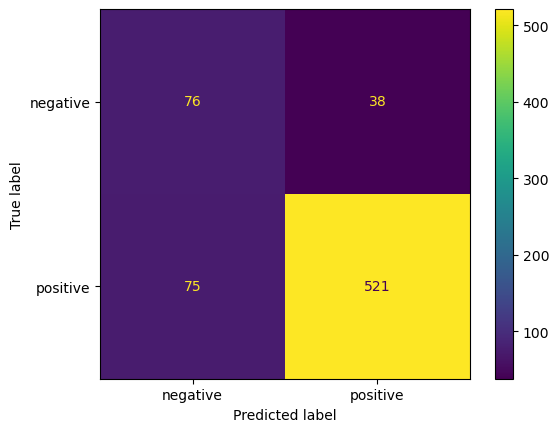

In [65]:
binary_df = df[df['sentiment'].isin(['positive','negative'])]
X_bin = vectorizer.fit_transform(binary_df['clean_text'])
y_bin = binary_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42,stratify=y_bin)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))

## Modélisation (Binaire: Positif vs Négatif)

### Interpretation (Binary model: positive vs negative)
- Precision is high for positive, while recall for negative is modest. This indicates the model misses some negative tweets (false negatives), likely due to class imbalance and overlap in vocabulary.
- Weighted metrics are dominated by the positive class. Consider stronger class weighting, threshold tuning, or collecting more negative examples to improve negative recall.
- The confusion matrix shows more errors where negatives are predicted as positive than the reverse; review representative false negatives for data or feature gaps.


## Multiclass Modeling (negative, neutral, positive)
We now train a 3-class model using the same TF-IDF features and Logistic Regression, with stratified splits and balanced class weights.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

    negative      0.307     0.509     0.383       114
     neutral      0.771     0.689     0.728      1109
    positive      0.570     0.611     0.589       596

    accuracy                          0.652      1819
   macro avg      0.549     0.603     0.567      1819
weighted avg      0.676     0.652     0.661      1819



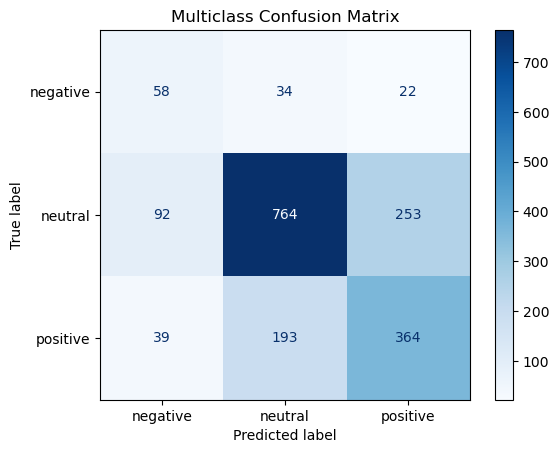

In [66]:
# Multiclass train/test, model, report, confusion matrix
X_mc = vectorizer.fit_transform(df['clean_text'])
Y_mc = df['sentiment']

Xtr_mc, Xte_mc, ytr_mc, yte_mc = train_test_split(
    X_mc, Y_mc, test_size=0.2, random_state=42, stratify=Y_mc
)

mc_model = LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='auto')
mc_model.fit(Xtr_mc, ytr_mc)
yp_mc = mc_model.predict(Xte_mc)

print(classification_report(yte_mc, yp_mc, digits=3))
ConfusionMatrixDisplay.from_estimator(mc_model, Xte_mc, yte_mc, cmap='Blues')
plt.title('Multiclass Confusion Matrix')
plt.show()


### Interpretation (Multiclass report and confusion matrix)
- Accuracy reflects the dominance of the neutral and positive classes; negative is the smallest class and typically has lower recall.
- Precision/recall trade-offs: If neutral recall is high but negative recall is low, the model is conservative about predicting negative.
- Confusion patterns: Most errors are confusions between neutral and positive; negatives are often misclassified as neutral. This suggests lexical overlap and limited negative examples.
- Mitigations: increase negative examples, adjust `class_weight`, incorporate bigrams, try SVM/LinearSVC, or calibrate decision thresholds.


In [67]:
# Top features per class (one-vs-rest weights)
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = mc_model.coef_
classes = mc_model.classes_

def top_features_for_class(class_index, k=20):
    coef = coefs[class_index]
    top_pos_idx = np.argsort(coef)[-k:][::-1]
    top_neg_idx = np.argsort(coef)[:k]
    return feature_names[top_pos_idx], coef[top_pos_idx], feature_names[top_neg_idx], coef[top_neg_idx]

k = 15
for i, label in enumerate(classes):
    pos_words, pos_w, neg_words, neg_w = top_features_for_class(i, k=k)
    print(f"\nClass: {label}")
    print("Top indicative terms (+):", ", ".join(pos_words))
    print("Top counter-indicative terms (-):", ", ".join(neg_words))



Class: negative
Top indicative terms (+): hate, headaches, tries, fail, long, ridic, enough, wont, iphone, fascist, button, launched, iphones, run, worst
Top counter-indicative terms (-): link, free, party, amp, googles, case, mobile, week, cool, downtown, popup, making, fun, awesome, check

Class: neutral
Top indicative terms (+): link, amp, mobile, designing, codes, today, event, austin, free, anyone, music, youre, valid, pm, turn
Top counter-indicative terms (-): ipad, app, cool, great, genius, wait, better, good, fail, ridic, tries, iphone, excited, concept, shit

Class: positive
Top indicative terms (+): cool, awesome, smart, great, fun, love, wins, ipad, wow, genius, hot, begins, nice, good, comes
Top counter-indicative terms (-): hate, wont, headaches, battery, enough, money, launchquot, doesnt, lost, long, says, yet, launching, people, thinks


### Interpreting feature weights
- Positive weights indicate terms that push predictions toward the class; negative weights pull away. Review the top terms for face validity and potential data leakage (e.g., brand or annotator artifacts).
- If negative class lacks strong indicators, consider adding bigrams, character n-grams, or sentiment lexicon features to capture negation and intensity.
- Use these lists to inform error analysis and data augmentation (e.g., curate more examples with underrepresented cues).


## Next steps and limitations
- Class imbalance: negative is scarce. Try stratified resampling, focal loss (other models), or targeted data collection.
- Features: add n-grams (1–2), character n-grams, and emoji/punctuation features; consider lemmatization.
- Models: compare LinearSVC, ComplementNB, and lightweight transformers (DistilBERT) with balanced sampling.
- Thresholds: calibrate probabilities and optimize per-class F1 or recall depending on the business objective.
- Monitoring: build a simple error log of most confident mistakes to prioritize data fixes.


In [68]:
# Save figures to disk for presentation
from pathlib import Path
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# 1) Class distribution pie chart (reuse counts from earlier cell)
counts = df['sentiment'].value_counts().reindex(['negative','neutral','positive']).fillna(0)
labels = counts.index.tolist()
colors = ['#d62728', '#7f7f7f', '#2ca02c']
plt.figure(figsize=(5,5))
plt.pie(counts.values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Class distribution (negative / neutral / positive)')
plt.axis('equal')
plt.savefig(fig_dir / 'class_distribution_pie.png', bbox_inches='tight', dpi=200)
plt.close()

# 2) Binary confusion matrix (retrain if needed)
binary_df = df[df['sentiment'].isin(['positive','negative'])]
X_bin = vectorizer.fit_transform(binary_df['clean_text'])
y_bin = binary_df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Reds')
plt.title('Binary Confusion Matrix')
plt.savefig(fig_dir / 'confusion_binary.png', bbox_inches='tight', dpi=200)
plt.close()

# 3) Multiclass confusion matrix (reuse mc_model)
ConfusionMatrixDisplay.from_estimator(mc_model, Xte_mc, yte_mc, cmap='Blues')
plt.title('Multiclass Confusion Matrix')
plt.savefig(fig_dir / 'confusion_multiclass.png', bbox_inches='tight', dpi=200)
plt.close()

# 4) Multiclass metrics bar chart (precision/recall/F1)
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(yte_mc, yp_mc, labels=classes)

x = np.arange(len(classes))
width = 0.25
plt.figure(figsize=(7,4))
plt.bar(x - width, prec, width, label='Precision')
plt.bar(x, rec, width, label='Recall')
plt.bar(x + width, f1, width, label='F1')
plt.xticks(x, classes)
plt.ylim(0, 1)
plt.title('Multiclass Metrics')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'metrics_multiclass.png', bbox_inches='tight', dpi=200)
plt.close()



### Interpretation (class distribution)
- The pie chart reveals the label imbalance. A large neutral slice means the model may default to “neutral.”
- Severe skew hurts minority recall (e.g., negative). Consider downsampling majorities, upweighting minorities (`class_weight='balanced'`), or more data collection.
- Always stratify train/test splits so the test set reflects the overall distribution.
